In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import scipy.stats as stats
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [8]:
# Load data
PATH = "/Users/wujiaqi/Desktop/427/academic_meals_elementary_district.csv" 
df = pd.read_csv(PATH)

print("Shape:", df.shape)
df.head()

Shape: (54, 263)


,District,ROE,student_disabilities_percent,student_low_income_percent,days_entered.x,HEI 2015 Total Score,HEI 2015 Total Fruits (0-5),HEI 2015 Whole Fruits (0-5),HEI 2015 Total Vegetables (0-5),HEI 2015 Greens and Beans (0-5),...,ELA_Proficiency_LowIncome,ELA_Proficiency_CWD,Math_Proficiency,Math_Proficiency_LowIncome,Math_Proficiency_CWD,Science_Proficiency,Science_Proficiency_LowIncome,Science_Proficiency_CWD,missing_frac,missing_count
0,AURORA EAST USD 131,31.0,16.0,70.0,20.0,59.977550,4.715150,4.69000,2.455950,1.343600,...,27.083333,77.300000,18.030769,18.172727,47.600000,36.25,53.833333,73.402085,0.1,1.0
1,BALL CHATHAM CUSD 5,51.0,19.0,23.9,20.0,51.193643,4.698247,5.00000,2.475737,0.683714,...,54.700000,36.050000,60.600000,40.025000,33.125000,48.10,20.300000,20.000000,0.0,0.0
2,BEECHER CUSD 200U,56.0,21.3,21.9,20.0,43.690050,1.022750,1.43120,3.511000,1.500000,...,62.900000,40.000000,45.600000,33.000000,19.700000,38.50,25.203549,44.725858,0.2,2.0
3,BRIMFIELD CUSD 309,48.0,12.4,16.8,20.0,60.763450,3.235850,4.80685,4.829950,3.072700,...,32.100000,35.769273,45.500000,20.400000,33.963590,54.20,27.216137,50.474703,0.4,4.0
4,CARRIER MILLS-STONEFORT CUSD 2,20.0,23.2,88.3,14.0,64.624500,5.000000,4.99050,2.944714,1.853357,...,42.000000,3.331603,9.700000,8.394519,5.610592,20.00,11.365037,18.500932,0.5,5.0


# Exploratory Data Analysis: School Meal Quality and Academic Performance

## Research Question

This analysis aims to investigate whether school meal nutrition quality is associated with academic performance across school districts.

Specifically, we examine:
- Whether higher nutrition quality (HEI score) is linked to better academic outcomes (Math, ELA)
- Whether this relationship is influenced by socioeconomic factors

In [11]:
# Key variables

# 1) Main nutrition measure used in the core analysis
MAIN_NUTRITION = "HEI 2015 Total Score"

# 2) HEI component scores
# These are on different scales (0-5, 0-10), so we keep them for
# descriptive analysis / heatmaps / PCA, and standardize them later.
NUTRITION_COMPONENT_CANDIDATES = [
    "HEI 2015 Total Fruits (0-5)",
    "HEI 2015 Whole Fruits (0-5)",
    "HEI 2015 Total Vegetables (0-5)",
    "HEI 2015 Greens and Beans (0-5)",
    "HEI 2015 Whole Grains (0-10)",
    "HEI 2015 Dairy (0-10)",
    "HEI 2015 Total Protein Foods (0-5)",
    "HEI 2015 Seafood and Plant Proteins (0-5)",
    "HEI 2015 Fatty Acids (0-10)",
    "HEI 2015 Refined Grains (0-10)",
    "HEI 2015 Sodium (0-10)",
    "HEI 2015 Added Sugars (0-10)",
    "HEI 2015 Saturated Fats (0-10)"
]

# 3) Academic outcomes
# Keep all subjects that exist, then you can analyze them separately
# and also build a composite academic index if needed.
OUTCOME_CANDIDATES = [
    "Math_Proficiency",
    "ELA_Proficiency",
    "Science_Proficiency"
]

# 4) Socioeconomic variable（here SES indicts social burden)
SES = "student_low_income_percent"

# 5) Optional controls (only keep if they exist in the dataset)
CONTROL_CANDIDATES = [
    "student_disabilities_percent"
]

# Keep only columns that actually exist
NUTRITION_COMPONENTS = [c for c in NUTRITION_COMPONENT_CANDIDATES if c in df.columns]
OUTCOME_VARS = [c for c in OUTCOME_CANDIDATES if c in df.columns]
CONTROL_VARS = [c for c in CONTROL_CANDIDATES if c in df.columns]

NUTRITION_VARS = [MAIN_NUTRITION] + NUTRITION_COMPONENTS
KEY_VARS = NUTRITION_VARS + OUTCOME_VARS + [SES] + CONTROL_VARS

# Remove duplicates while preserving order
KEY_VARS = list(dict.fromkeys(KEY_VARS))

print("Nutrition variables:")
print(NUTRITION_VARS)

print("\nOutcome variables:")
print(OUTCOME_VARS)

print("\nControl variables:")
print([SES] + CONTROL_VARS)

# Convert to numeric
for col in KEY_VARS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Optional: Create an overall academic performance index (The Mean of Science, Math and ELA)
if len(OUTCOME_VARS) >= 2:
    df["Academic_Performance_Index"] = df[OUTCOME_VARS].mean(axis=1)
    print("\nCreated: Academic_Performance_Index")

# Optional: standardize HEI components which have different scale
# Use standardized components for heatmap / PCA / multivariable analysis
# Do NOT replace the original Total Score
if len(NUTRITION_COMPONENTS) > 0:
    scaler = StandardScaler()
    df[[f"{c}_z" for c in NUTRITION_COMPONENTS]] = scaler.fit_transform(df[NUTRITION_COMPONENTS])

    NUTRITION_COMPONENTS_Z = [f"{c}_z" for c in NUTRITION_COMPONENTS]
    print("\nCreated standardized nutrition component variables:")
    print(NUTRITION_COMPONENTS_Z)
else:
    NUTRITION_COMPONENTS_Z = []

Nutrition variables:
['HEI 2015 Total Score', 'HEI 2015 Total Fruits (0-5)', 'HEI 2015 Whole Fruits (0-5)', 'HEI 2015 Total Vegetables (0-5)', 'HEI 2015 Greens and Beans (0-5)', 'HEI 2015 Whole Grains (0-10)', 'HEI 2015 Dairy (0-10)', 'HEI 2015 Total Protein Foods (0-5)', 'HEI 2015 Seafood and Plant Proteins (0-5)', 'HEI 2015 Fatty Acids (0-10)', 'HEI 2015 Refined Grains (0-10)', 'HEI 2015 Sodium (0-10)', 'HEI 2015 Added Sugars (0-10)', 'HEI 2015 Saturated Fats (0-10)']

Outcome variables:
['Math_Proficiency', 'ELA_Proficiency', 'Science_Proficiency']

Control variables:
['student_low_income_percent', 'student_disabilities_percent']

Created: Academic_Performance_Index

Created standardized nutrition component variables:
['HEI 2015 Total Fruits (0-5)_z', 'HEI 2015 Whole Fruits (0-5)_z', 'HEI 2015 Total Vegetables (0-5)_z', 'HEI 2015 Greens and Beans (0-5)_z', 'HEI 2015 Whole Grains (0-10)_z', 'HEI 2015 Dairy (0-10)_z', 'HEI 2015 Total Protein Foods (0-5)_z', 'HEI 2015 Seafood and Plant

## 1. Summary Statistics

We begin by examining summary statistics of key variables to understand their distributions and variability across districts.

This helps identify potential skewness, extreme values, and differences in scale across variables.

In [14]:
summary_table = df[KEY_VARS].describe().T
summary_table ##We've already remove the missing data

,count,mean,std,min,25%,50%,75%,max
HEI 2015 Total Score,54.0,57.217577,8.354165,38.461524,52.105363,58.951686,62.813546,75.578250
HEI 2015 Total Fruits (0-5),54.0,3.556256,1.520923,0.000000,2.835012,4.148682,4.839184,5.000000
HEI 2015 Whole Fruits (0-5),54.0,4.074195,1.412033,0.000000,4.039262,4.694095,4.938831,5.000000
HEI 2015 Total Vegetables (0-5),54.0,3.036338,1.037960,0.697143,2.264696,3.120129,3.889198,4.960368
HEI 2015 Greens and Beans (0-5),54.0,1.631814,0.964138,0.000000,1.101737,1.585214,2.163216,5.000000
HEI 2015 Whole Grains (0-10),54.0,3.536369,2.271207,0.327000,1.567431,3.148555,5.600161,7.642700
HEI 2015 Dairy (0-10),54.0,8.339548,2.318075,2.571200,6.396052,9.698933,10.000000,10.000000
HEI 2015 Total Protein Foods (0-5),54.0,3.529900,0.785891,2.002647,3.049536,3.421457,4.139778,4.956286
HEI 2015 Seafood and Plant Proteins (0-5),54.0,1.785157,1.425402,0.000000,0.754808,1.265174,2.325179,5.000000
HEI 2015 Fatty Acids (0-10),54.0,4.324255,1.595595,1.380650,3.155000,4.238502,5.190335,8.488714


## 2. Distribution of Key Variables

We visualize the distributions of the main nutrition variable, academic outcomes, and SES to understand variation across districts.

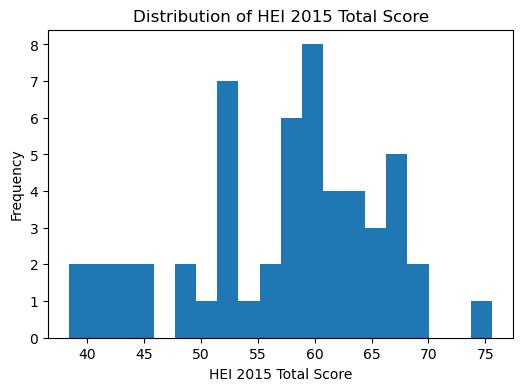

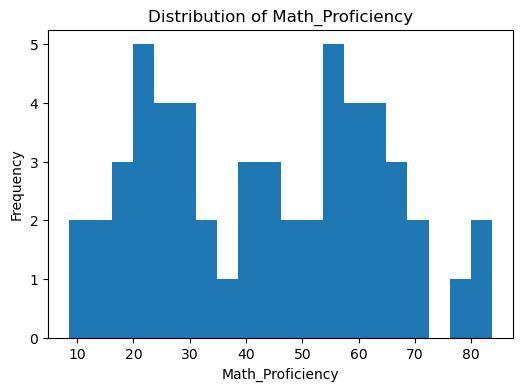

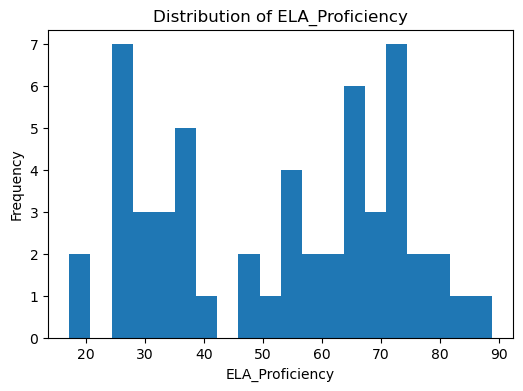

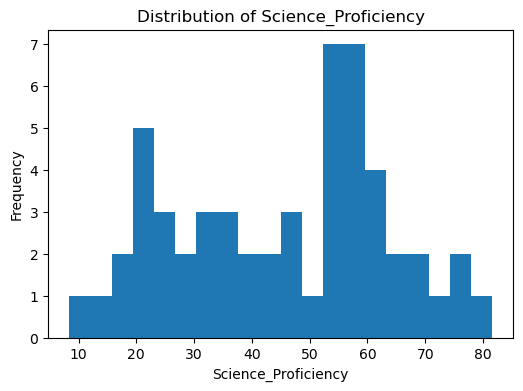

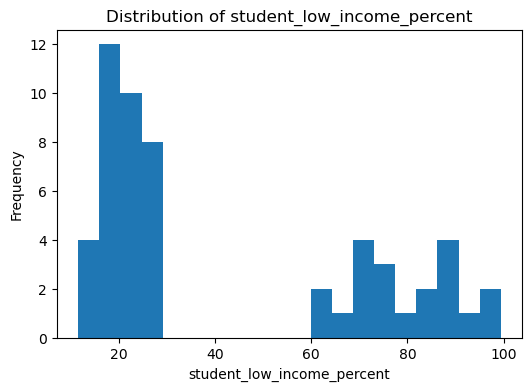

In [17]:
# Histograms
plot_vars = [MAIN_NUTRITION] + OUTCOME_VARS + [SES]

for var in plot_vars:
    plt.figure(figsize=(6, 4))
    plt.hist(df[var].dropna(), bins=20)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()

## 3. Academic Performance Across Nutrition Levels

To explore the relationship between meal quality and student outcomes, districts are grouped into quartiles based on the HEI 2015 Total Score.

We then compare average academic performance across nutrition quartiles.

In [20]:
#Nutrition quartiles
df["nutrition_q"] = pd.qcut(
    df[MAIN_NUTRITION],
    4,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]
)

quartile_means = df.groupby("nutrition_q")[OUTCOME_VARS].mean()
quartile_means

/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_86346/3572583906.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_means = df.groupby("nutrition_q")[OUTCOME_VARS].mean()


,Math_Proficiency,ELA_Proficiency,Science_Proficiency
nutrition_q,,,
Q1 (lowest),51.671310,62.372976,53.032568
Q2,44.862553,51.754028,44.356415
Q3,38.811480,47.760645,44.869739
Q4 (highest),37.249116,47.034821,39.070499


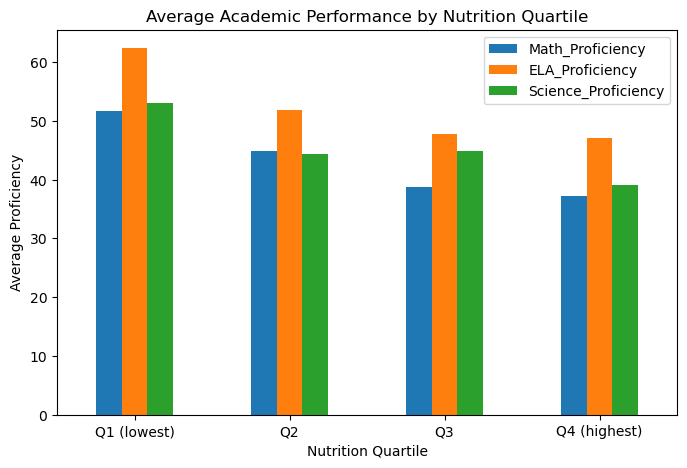

In [22]:
#Plot quartile comparison
quartile_means.plot(kind="bar", figsize=(8, 5))
plt.title("Average Academic Performance by Nutrition Quartile")
plt.xlabel("Nutrition Quartile")
plt.ylabel("Average Proficiency")
plt.xticks(rotation=0)
plt.show()

## Conclusion

Figure shows average academic performance across quartiles of nutrition quality.

Surprisingly, districts with higher nutrition scores tend to have lower
average performance in Math, ELA, and Science. This negative association
is consistent across all subjects.

However, this pattern is likely driven by socioeconomic differences.
Districts with higher proportions of low-income students may receive
greater nutritional support, resulting in higher HEI scores, while also
facing structural disadvantages that negatively affect academic outcomes.

Therefore, the observed relationship should not be interpreted as causal.

## 4. Correlation Structure

We examine correlations among nutrition, academic outcomes, and SES to identify broad patterns and potential confounding relationships.

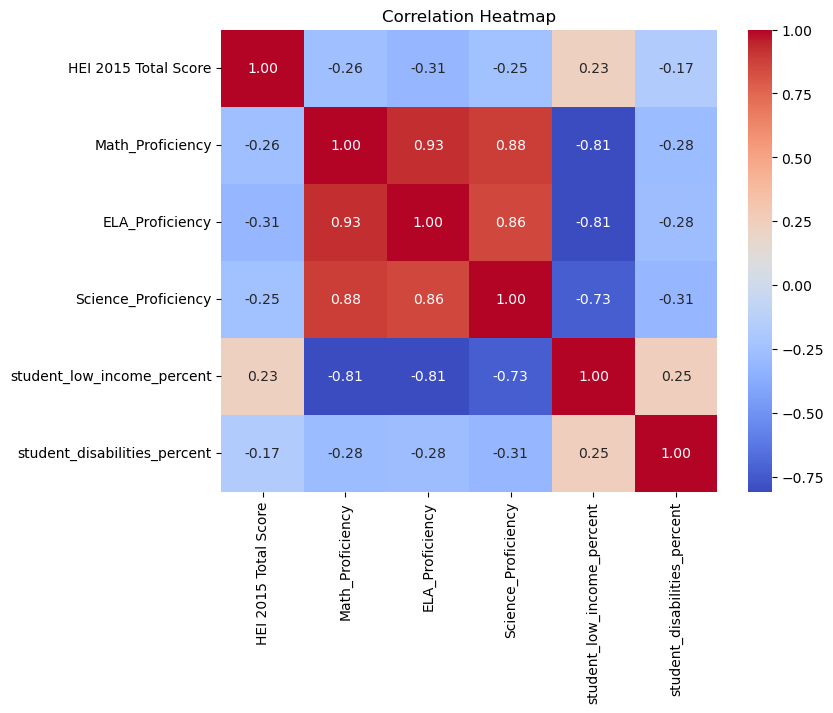

In [26]:
#Heatmap using main variables
heatmap_vars = [MAIN_NUTRITION] + OUTCOME_VARS + [SES] + CONTROL_VARS
corr = df[heatmap_vars].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

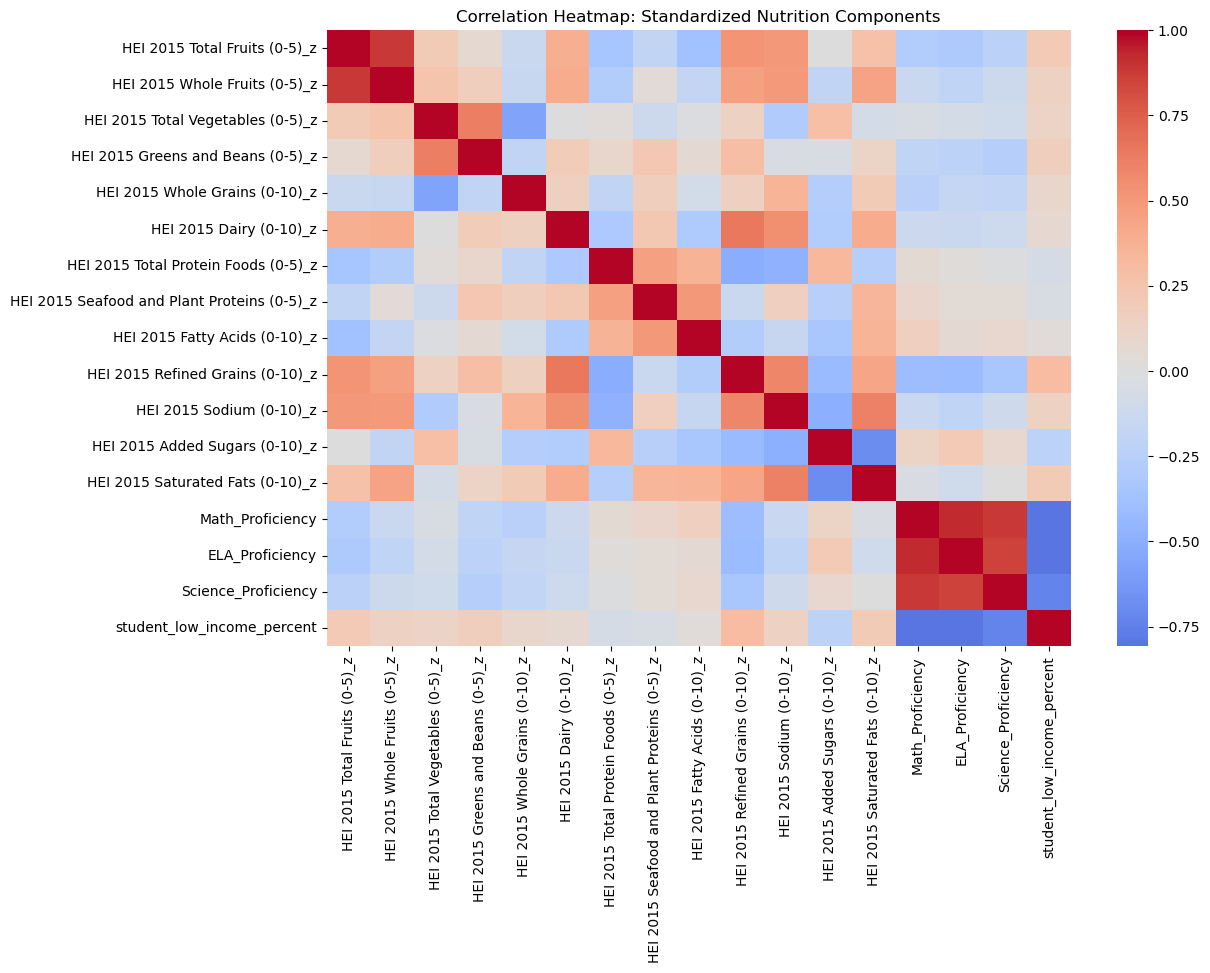

In [28]:
#Optional heatmap using standardized nutrition components
if len(NUTRITION_COMPONENTS_Z) > 0:
    component_heatmap_vars = NUTRITION_COMPONENTS_Z + OUTCOME_VARS + [SES]
    corr_components = df[component_heatmap_vars].corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_components, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap: Standardized Nutrition Components")
    plt.show()

## Results and Interpretation

The correlation analysis at the district level reveals several important patterns. First, academic outcomes are highly positively correlated across subjects, with strong associations between Math, ELA, and Science proficiency. This indicates that districts performing well in one subject tend to perform well across all subjects, suggesting a consistent underlying performance structure.

Second, socioeconomic status emerges as the dominant factor associated with academic performance. The percentage of low-income students is strongly negatively correlated with all academic outcomes, with correlations around -0.8. This suggests that districts with higher levels of economic disadvantage tend to have substantially lower academic performance across all subjects.

In contrast, the overall nutrition measure (HEI 2015 Total Score) shows a weak negative correlation with academic outcomes. While this may initially appear counterintuitive, the magnitude of the relationship is relatively small compared to the strong association between socioeconomic status and performance. This pattern suggests that the observed relationship between nutrition and academic outcomes is likely influenced by underlying socioeconomic differences across districts rather than reflecting a direct causal effect.

Further analysis using standardized nutrition components reinforces this conclusion. The component-level heatmap shows that nutrition quality is multidimensional, with different components capturing distinct dietary patterns. However, correlations between individual nutrition components and academic outcomes are generally weak and inconsistent. No single nutrition component exhibits a strong or systematic relationship with performance across subjects.

Taken together, these findings indicate that while nutrition quality varies across districts, it does not appear to be a primary driver of differences in academic performance. Instead, socioeconomic factors play a much more substantial role. Therefore, the relationship between nutrition and academic outcomes observed in this analysis should be interpreted cautiously, as it is likely confounded by socioeconomic conditions rather than representing a direct causal relationship.

## 5. Scatterplots: Nutrition and Academic Performance

We visualize the relationship between the HEI 2015 Total Score and each academic outcome using scatterplots with fitted regression lines.

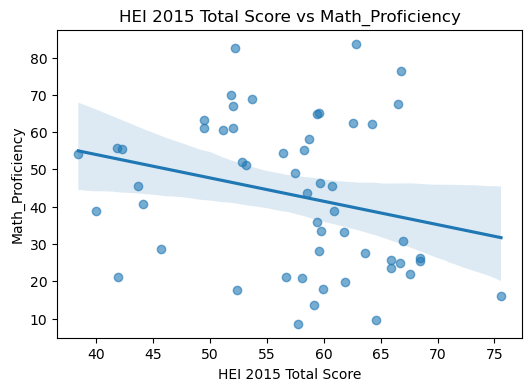

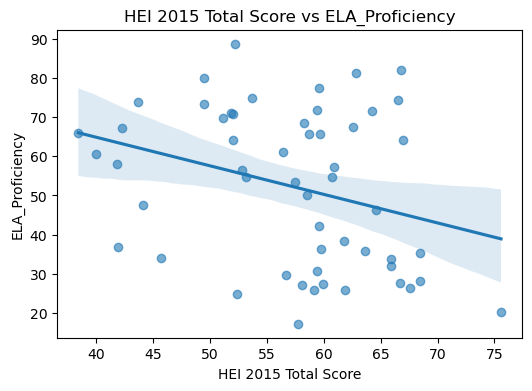

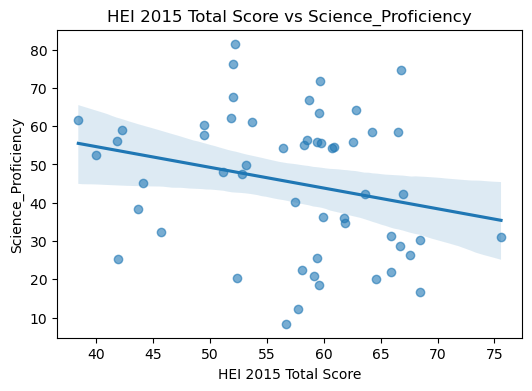

In [32]:
for outcome in OUTCOME_VARS:
    plt.figure(figsize=(6, 4))
    sns.regplot(data=df, x=MAIN_NUTRITION, y=outcome, scatter_kws={"alpha": 0.6})
    plt.title(f"{MAIN_NUTRITION} vs {outcome}")
    plt.xlabel(MAIN_NUTRITION)
    plt.ylabel(outcome)
    plt.show()

Scatterplots of HEI 2015 Total Score against academic outcomes reveal a
consistent negative trend across Math, ELA, and Science proficiency.

In all three cases, the fitted regression lines slope downward, suggesting
that districts with higher nutrition scores tend to have lower average
academic performance. However, the relationship is weak, as indicated by
the wide dispersion of points and substantial variability across districts.

The consistency of the negative trend across subjects suggests that this
pattern is not driven by a single outcome. Nevertheless, the weak magnitude
of the relationship and the large variability indicate that nutrition
quality alone does not strongly explain differences in academic performance.

Combined with earlier findings, this pattern is likely driven by
socioeconomic confounding. Districts with higher proportions of low-income
students may receive greater nutritional support, resulting in higher HEI
scores, while also facing structural disadvantages that negatively impact
academic outcomes.

Therefore, the observed negative association between nutrition quality
and academic performance should not be interpreted as causal.

## 6. Socioeconomic Status and Potential Confounding

Because socioeconomic status may influence both nutrition quality and academic performance, we examine variation across SES groups.

In [36]:
#SES quartiles
df["ses_q"] = pd.qcut(
    df[SES],
    4,
    labels=["Q1 (lowest SES burden)", "Q2", "Q3", "Q4 (highest SES burden)"]
)

ses_means = df.groupby("ses_q")[[MAIN_NUTRITION] + OUTCOME_VARS].mean()
ses_means

/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_86346/2852261214.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses_means = df.groupby("ses_q")[[MAIN_NUTRITION] + OUTCOME_VARS].mean()


,HEI 2015 Total Score,Math_Proficiency,ELA_Proficiency,Science_Proficiency
ses_q,,,,
Q1 (lowest SES burden),57.244018,57.894337,64.287143,55.698389
Q2,50.954508,57.408974,68.786655,57.945504
Q3,61.159179,36.991114,46.148456,42.316007
Q4 (highest SES burden),59.346782,21.066180,30.801676,26.157562


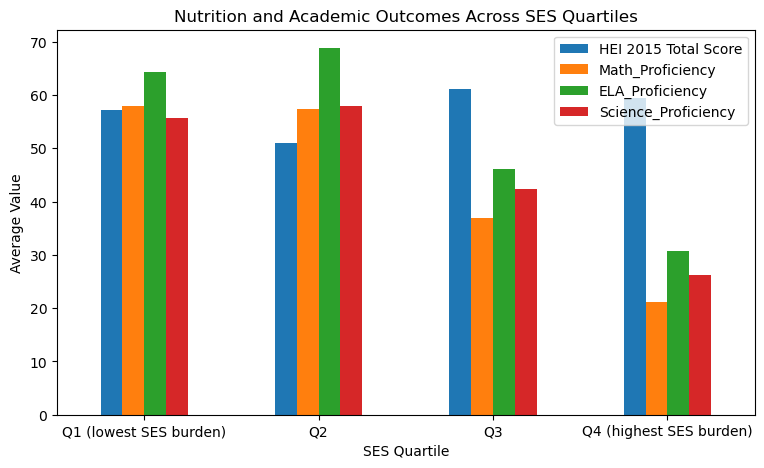

In [38]:
#Plot SES comparision
ses_means.plot(kind="bar", figsize=(9, 5))
plt.title("Nutrition and Academic Outcomes Across SES Quartiles")
plt.xlabel("SES Quartile")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

Figure above shows nutrition quality and academic outcomes across SES quartiles.

As the socioeconomic burden increases (from Q1 to Q4), academic performance
declines sharply across all subjects, with substantial drops in Math, ELA,
and Science proficiency. This indicates a strong negative association
between SES and academic outcomes.

In contrast, nutrition quality, measured by the HEI 2015 Total Score,
increases with SES burden. Districts with higher proportions of low-income
students tend to have higher nutrition scores, possibly reflecting
targeted meal programs and nutritional support.

These opposing trends suggest that the observed negative relationship
between nutrition and academic performance is driven by socioeconomic
confounding. Rather than indicating that better nutrition leads to lower
performance, the pattern reflects that disadvantaged districts both
receive more nutritional support and face structural challenges that
negatively affect academic outcomes.

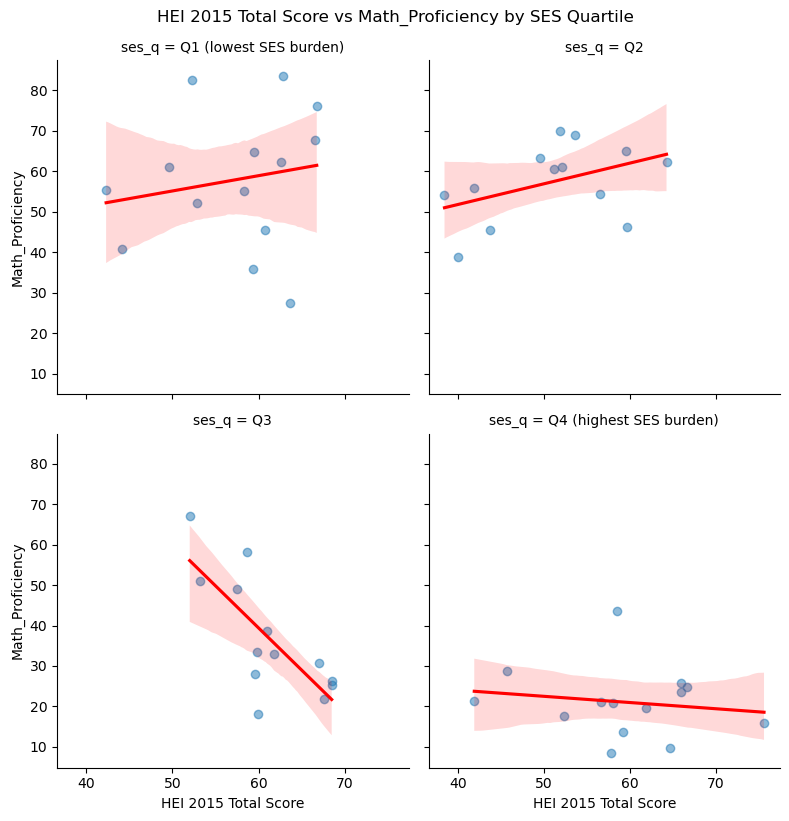

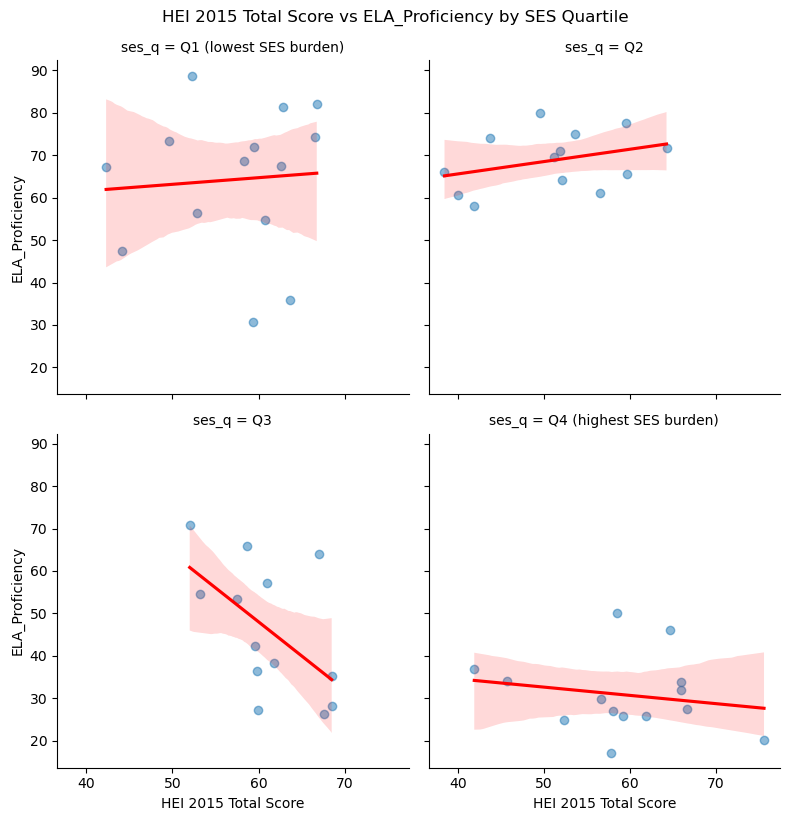

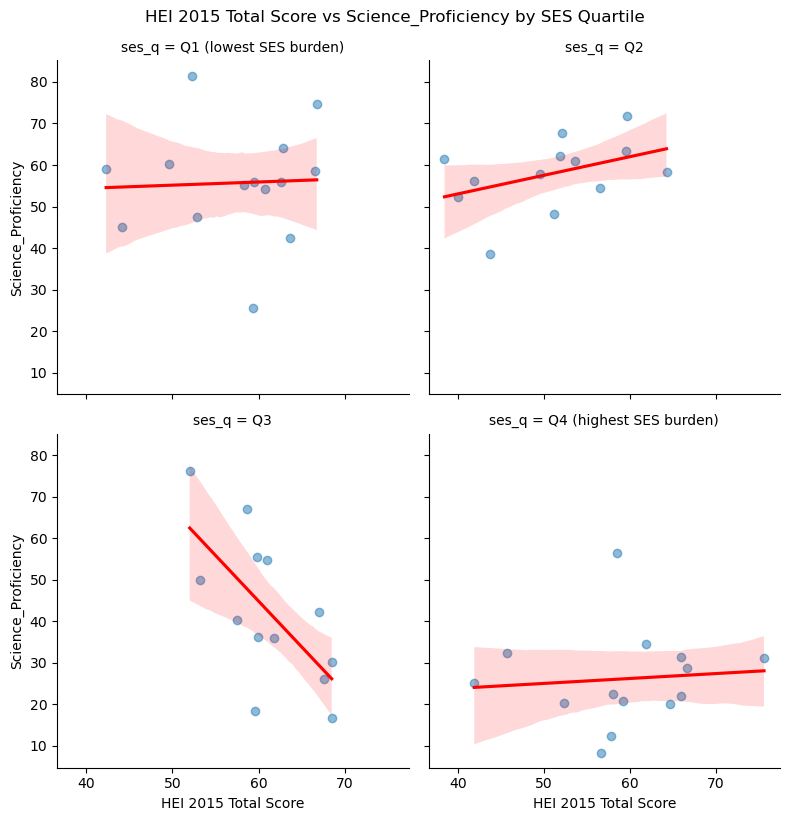

In [41]:
#Optional subgroup scatterplots by SES quartile
for outcome in OUTCOME_VARS:
    g = sns.lmplot(
        data=df,
        x=MAIN_NUTRITION,
        y=outcome,
        col="ses_q",
        col_wrap=2,
        height=4,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )
    g.fig.suptitle(f"{MAIN_NUTRITION} vs {outcome} by SES Quartile", y=1.02)
    plt.show()

To further investigate the role of socioeconomic status, we examine the
relationship between nutrition quality and academic performance within
each SES quartile.

The results reveal substantial heterogeneity across SES groups. In
districts with lower socioeconomic burden (Q1 and Q2), the relationship
between nutrition quality and academic performance is weakly positive or
negligible. This suggests that in more advantaged districts, better
nutrition may be associated with slightly improved academic outcomes.

However, in districts with higher socioeconomic burden (Q3 and Q4), the
relationship becomes weaker or even negative. This indicates that in more
disadvantaged districts, other structural factors likely dominate
academic performance, reducing the apparent effect of nutrition.

Overall, these findings demonstrate that the relationship between
nutrition and academic performance is not consistent across contexts and
is strongly influenced by socioeconomic conditions.

## 7. Exploratory Regression Analysis

This section uses regression analysis to explore whether nutrition quality
is associated with academic performance and whether this relationship
remains after accounting for socioeconomic differences.

In [45]:
#Regression: one outcome at a time
for outcome in OUTCOME_VARS:
    print("\n" + "=" * 70)
    print(f"Outcome: {outcome}")
    print("=" * 70)

    # Model 1: Nutrition only
    X1 = sm.add_constant(df[[MAIN_NUTRITION]])
    y = df[outcome]
    model1 = sm.OLS(y, X1, missing="drop").fit()
    print("\nModel 1: Nutrition only")
    print(model1.summary())

    # Model 2: Nutrition + SES
    X2_vars = [MAIN_NUTRITION, SES] + CONTROL_VARS
    X2 = sm.add_constant(df[X2_vars])
    model2 = sm.OLS(y, X2, missing="drop").fit()
    print("\nModel 2: Nutrition + SES (+ controls if available)")
    print(model2.summary())


Outcome: Math_Proficiency

Model 1: Nutrition only
                            OLS Regression Results                            
Dep. Variable:       Math_Proficiency   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     3.787
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0571
Time:                        18:37:21   Log-Likelihood:                -236.27
No. Observations:                  54   AIC:                             476.5
Df Residuals:                      52   BIC:                             480.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [47]:
#Optional regression using Academic Performance Index
if "Academic_Performance_Index" in df.columns:
    X1 = sm.add_constant(df[[MAIN_NUTRITION]])
    y = df["Academic_Performance_Index"]
    model1_index = sm.OLS(y, X1, missing="drop").fit()

    X2_vars = [MAIN_NUTRITION, SES] + CONTROL_VARS
    X2 = sm.add_constant(df[X2_vars])
    model2_index = sm.OLS(y, X2, missing="drop").fit()

    print("\n" + "=" * 70)
    print("Outcome: Academic_Performance_Index")
    print("=" * 70)
    print("\nModel 1: Nutrition only")
    print(model1_index.summary())
    print("\nModel 2: Nutrition + SES (+ controls if available)")
    print(model2_index.summary())


Outcome: Academic_Performance_Index

Model 1: Nutrition only
                                OLS Regression Results                                
Dep. Variable:     Academic_Performance_Index   R-squared:                       0.080
Model:                                    OLS   Adj. R-squared:                  0.062
Method:                         Least Squares   F-statistic:                     4.529
Date:                        Sun, 22 Mar 2026   Prob (F-statistic):             0.0381
Time:                                18:37:23   Log-Likelihood:                -231.98
No. Observations:                          54   AIC:                             468.0
Df Residuals:                              52   BIC:                             471.9
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                           coef    std err          t      P>|t|    

## Results

In this section, we conduct exploratory regression analysis to examine
the relationship between nutrition quality and academic performance.

In the baseline model, nutrition quality (HEI 2015 Total Score) shows a
statistically significant negative association with academic performance.
However, the explanatory power of this model is limited, as indicated by
a low R-squared value.

After controlling for socioeconomic status, the effect of nutrition
becomes statistically insignificant, while the socioeconomic variable
remains highly significant. Additionally, the model's explanatory power
increases substantially, suggesting that socioeconomic factors account
for most of the variation in academic outcomes.

Further analysis of individual nutrition components reveals only weak
correlations with academic performance, with no strong or consistent
patterns emerging.

Overall, these results suggest that the observed relationship between
nutrition and academic performance is largely driven by socioeconomic
differences rather than a direct effect of nutrition.

In [50]:
#Optional component-level analysis
if len(NUTRITION_COMPONENTS_Z) > 0:
    for outcome in OUTCOME_VARS:
        component_corr = df[NUTRITION_COMPONENTS_Z + [outcome]].corr()[outcome].sort_values(ascending=False)
        print(f"\nCorrelations with {outcome}:")
        print(component_corr)


Correlations with Math_Proficiency:
Math_Proficiency                               1.000000
HEI 2015 Fatty Acids (0-10)_z                  0.158849
HEI 2015 Added Sugars (0-10)_z                 0.118702
HEI 2015 Seafood and Plant Proteins (0-5)_z    0.100208
HEI 2015 Total Protein Foods (0-5)_z           0.049616
HEI 2015 Saturated Fats (0-10)_z              -0.031261
HEI 2015 Total Vegetables (0-5)_z             -0.038984
HEI 2015 Dairy (0-10)_z                       -0.126247
HEI 2015 Whole Fruits (0-5)_z                 -0.132881
HEI 2015 Sodium (0-10)_z                      -0.139204
HEI 2015 Greens and Beans (0-5)_z             -0.194605
HEI 2015 Whole Grains (0-10)_z                -0.237744
HEI 2015 Total Fruits (0-5)_z                 -0.281195
HEI 2015 Refined Grains (0-10)_z              -0.410156
Name: Math_Proficiency, dtype: float64

Correlations with ELA_Proficiency:
ELA_Proficiency                                1.000000
HEI 2015 Added Sugars (0-10)_z                 0

To further explore the relationship between specific dietary factors and
academic performance, we examine pairwise correlations between individual
nutrition components and outcome variables.

Across all subjects, the correlations between nutrition components and
academic performance are generally weak, with most coefficients falling
within the range of -0.4 to 0.2. No strong or consistent patterns emerge
across subjects.

In addition, some correlations exhibit counterintuitive directions. For
example, certain healthy components such as fruits and vegetables show
negative correlations with academic outcomes, while some less healthy
components show weak positive associations. These patterns suggest that
the observed relationships may be driven by underlying socioeconomic
differences rather than direct nutritional effects.

Overall, this analysis provides further evidence that individual nutrition
components do not exhibit strong independent associations with academic
performance at the district level.

## Principal Component Analysis (PCA)

In the previous analysis, we examined the relationship between individual nutrition variables and academic performance. However, the results did not reveal strong or consistent independent associations. This may be due to the high dimensionality and strong correlations among the nutrition variables.

Many of the nutrition components (e.g., fruits, vegetables, fats, and sugars) are inherently correlated, which can lead to multicollinearity and unstable estimates in regression models. As a result, analyzing these variables individually may fail to capture the underlying dietary structure.

To address these issues, we apply Principal Component Analysis (PCA) to the standardized nutrition variables. PCA reduces the dimensionality of the data by transforming the original variables into a smaller set of uncorrelated components (principal components), each representing a combination of dietary features.

These principal components can be interpreted as underlying dietary patterns across districts (e.g., healthier vs. less healthy diets). By focusing on these patterns rather than individual variables, we can better understand the overall structure of nutrition and its potential relationship with academic outcomes.

Importantly, PCA is used here as a dimensionality reduction and exploratory tool. It does not imply causality, but helps identify meaningful structure in the data for further analysis.

In [54]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df[NUTRITION_COMPONENTS].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [56]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.32373201, 0.19621114, 0.16235259, 0.08433828, 0.0806112 ,
       0.04177883, 0.02751204, 0.02400959, 0.02017975, 0.01651572,
       0.0120016 , 0.00731239, 0.00344486])

We examine the explained variance ratio of the principal components to determine how many components to retain.

The first few components capture a substantial portion of the total variance. Specifically, the first three principal components explain approximately 68% of the total variance, while the first four components explain over 75%.

Based on this, we retain the first 4 principal components for further analysis, as they capture the majority of the variation in the nutrition data.

In [59]:
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
df["PC3"] = X_pca[:, 2]
df["PC4"] = X_pca[:, 3]

In [61]:
X_vars = ["PC1", "PC2", "PC3", "PC4","student_low_income_percent"]

X = sm.add_constant(df[X_vars])
y = df["Academic_Performance_Index"]

model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                                OLS Regression Results                                
Dep. Variable:     Academic_Performance_Index   R-squared:                       0.686
Model:                                    OLS   Adj. R-squared:                  0.653
Method:                         Least Squares   F-statistic:                     20.94
Date:                        Sun, 22 Mar 2026   Prob (F-statistic):           4.83e-11
Time:                                18:37:35   Log-Likelihood:                -202.99
No. Observations:                          54   AIC:                             418.0
Df Residuals:                              48   BIC:                             429.9
Df Model:                                   5                                         
Covariance Type:                    nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

## Final Conclusion

In this analysis, we investigate the relationship between school meal nutrition quality and academic performance across districts.

Initial results based on aggregate nutrition measures suggest a potential association between nutrition and academic outcomes. However, further analysis reveals that this relationship is not robust.

When controlling for socioeconomic status, the effect of nutrition becomes statistically insignificant, while socioeconomic variables remain consistently strong predictors of academic performance.

To further examine this, we incorporate detailed nutrition components and apply Principal Component Analysis (PCA) to capture underlying dietary patterns. Across multiple specifications—retaining three, four, and five principal components—none of the nutrition-related variables are statistically significant.

These consistent findings indicate that the apparent relationship between nutrition and academic performance is largely driven by socioeconomic differences rather than a direct independent effect of nutrition.

Overall, this study suggests that improving academic outcomes may require addressing broader socioeconomic inequalities, as nutrition alone does not appear to be a primary driver at the district level.